# Gaussian PSF - WIP!

This notebook explores the implementation and visualization of Gaussian Point Spread Functions (PSFs) within the HEALPix framework. It demonstrates how to define PSFs, apply them to geospatial data, and analyze their effects on HEALPix cell assignments. As a Work In Progress (WIP), the content is exploratory and subject to significant API changes and refinements.

## Setup

Import the healpyxel package and core utilities:

In [ ]:
# Import the GaussianPSF class from healpyxel.sidecar
from healpyxel.sidecar import GaussianPSF

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Create a Gaussian PSF with a chosen sigma
sigma = 1.0
psf = GaussianPSF(sigma=sigma)

# Create a grid of (dx, dy) values
grid_size = 100
extent = 3 * sigma
x = np.linspace(-extent, extent, grid_size)
y = np.linspace(-extent, extent, grid_size)
dx, dy = np.meshgrid(x, y)

# Evaluate the PSF on the grid
z = psf(dx, dy)

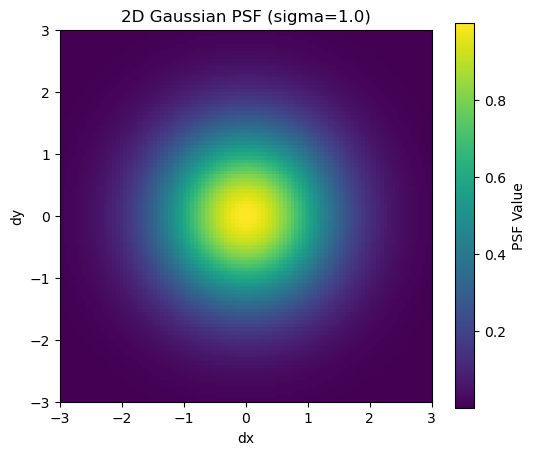

In [ ]:
plt.figure(figsize=(6, 5))
plt.imshow(z, extent=[-extent, extent, -extent, extent], origin='lower', cmap='viridis')
plt.colorbar(label='PSF Value')
plt.title(f'2D Gaussian PSF (sigma={sigma})')
plt.xlabel('dx')
plt.ylabel('dy')
plt.show()

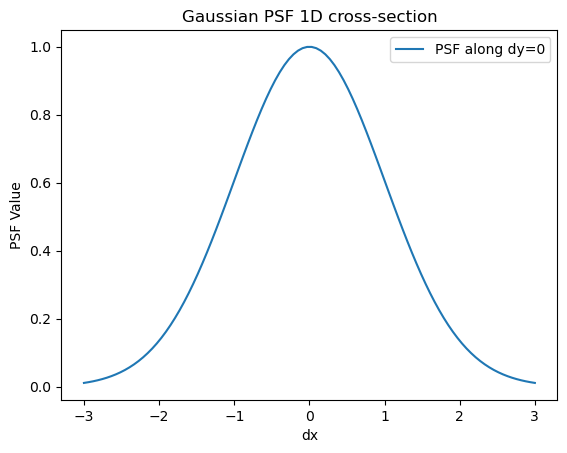

In [ ]:
plt.figure()
plt.plot(x, psf(x, 0), label='PSF along dy=0')
plt.title('Gaussian PSF 1D cross-section')
plt.xlabel('dx')
plt.ylabel('PSF Value')
plt.legend()
plt.show()

In [ ]:
from pathlib import Path

# Look for test data
test_data_dir = Path('../test_data')
if test_data_dir.exists():
    print("Test data directory found!")
    print(f"\nContents:")
    for item in sorted(test_data_dir.iterdir()):
        if item.is_file():
            size_mb = item.stat().st_size / 1024 / 1024
            print(f"  {item.name}: {size_mb:.2f} MB")
        elif item.is_dir():
            n_files = len(list(item.glob('*')))
            print(f"  {item.name}/: {n_files} files")
else:
    print("Test data directory not found. Run create_test_data.sh to generate test data.")

Test data directory found!

Contents:
  README.md: 0.00 MB
  batches/: 10 files
  derived/: 1 files
  regions/: 0 files
  samples/: 3 files
  validation/: 2 files


In [ ]:
from healpyxel.sidecar import process_partition, write_coalesced_output, get_psf
import pandas as pd
from pathlib import Path
import geopandas as gpd
from shapely import wkb

# Load your test data
input_path = test_data_dir / 'batches' / 'batch_001.parquet'
# Read as regular pandas DataFrame first (geometry is stored as WKB binary)
df = pd.read_parquet(input_path)

print(f"Loaded {len(df)} rows")
print(f"Columns: {list(df.columns)}")

# Convert WKB geometry column to shapely geometries
if 'geometry' in df.columns:
    print("\nConverting WKB geometry to GeoDataFrame...")
    df['geometry'] = df['geometry'].apply(lambda x: wkb.loads(bytes(x)) if x is not None else None)
    gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')
    print(f"CRS: {gdf.crs}")
else:
    print("\nNo geometry column found!")
    gdf = df

# Show first few rows
gdf.head(3)

Loaded 3029 rows
Columns: ['ref_id', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q1', 'q2', 'q3', 'q4', 'obs_id', 'vis_slope', 'nir_slope', 'visnir_slope', 'norm_vis_slope', 'norm_nir_slope', 'norm_visnir_slope', 'curvature', 'norm_curvature', 'uv_downturn', 'color_index_310_390', 'color_index_415_750', 'color_index_750_415', 'color_index_750_950', 'r310', 'r390', 'r750', 'r950', 'r1050', 'r1400', 'r415', 'r433_2', 'r479_9', 'r556_9', 'r628_8', 'r748_7', 'r828_4', 'r898_8', 'r996_2', 'spot_number', 'lat_center', 'lon_center', 'surface', 'width', 'length', 'ang_incidence', 'ang_emission', 'ang_phase', 'azimuth', 'geometry']

Converting WKB geometry to GeoDataFrame...
CRS: EPSG:4326


,ref_id,a,b,c,d,e,f,g,h,i,...,lat_center,lon_center,surface,width,length,ang_incidence,ang_emission,ang_phase,azimuth,geometry
0,0801419125400568,0,0,0,0,0,1,0,0,0,...,1.069630,175.06512,54194396.0,5599.9224,12322.036,9.834717,73.333954,83.013830,154.51570,"POLYGON ((175.18568 1.15206, 175.0281 1.12375,..."
1,0801419125400569,0,0,0,0,0,1,0,0,0,...,1.121209,175.14010,54753300.0,5660.6910,12315.469,9.769003,73.381120,82.985110,154.42958,"POLYGON ((175.25902 1.20378, 175.10211 1.17589..."
2,0801419125400570,0,0,0,0,0,1,0,0,0,...,1.173109,175.21364,54823684.0,5736.7520,12167.806,9.704690,73.427300,82.956314,154.33447,"POLYGON ((175.32878 1.25573, 175.1742 1.22806,..."


In [ ]:
gdf['lon_center'].describe()

count    3029.000000
mean      175.486985
std         0.295076
min       175.000180
25%       175.228490
50%       175.482590
75%       175.747380
max       175.999080
Name: lon_center, dtype: float64

In [ ]:
import numpy as np

def healpix_cell_diameter_deg(nside):
    # Area of a HEALPix cell (steradians)
    area_sr = 4 * np.pi / (12 * nside * nside)
    # Convert to square degrees
    area_deg2 = area_sr * (180/np.pi)**2
    # Equivalent diameter (degrees) for a circle of this area
    diameter_deg = 2 * np.sqrt(area_deg2 / np.pi)
    return diameter_deg
    

In [ ]:
# Set parameters
nside = 32
mode = "fuzzy"
lon_convention = "0_360"
sigma_level = 0.01  # Number of sigma to cover the cell
cell_radius = healpix_cell_diameter_deg(nside) / 2
sigma = cell_radius / sigma_level
cell_psf = get_psf("gaussian", sigma=sigma)  # You can adjust sigma as needed
print(f"{cell_radius=}")
print(f"{sigma_level=}")
print(f"{sigma=:}")

cell_radius=np.float64(1.03374167891586)
sigma_level=0.01
sigma=103.374167891586


<Figure size 640x480 with 0 Axes>

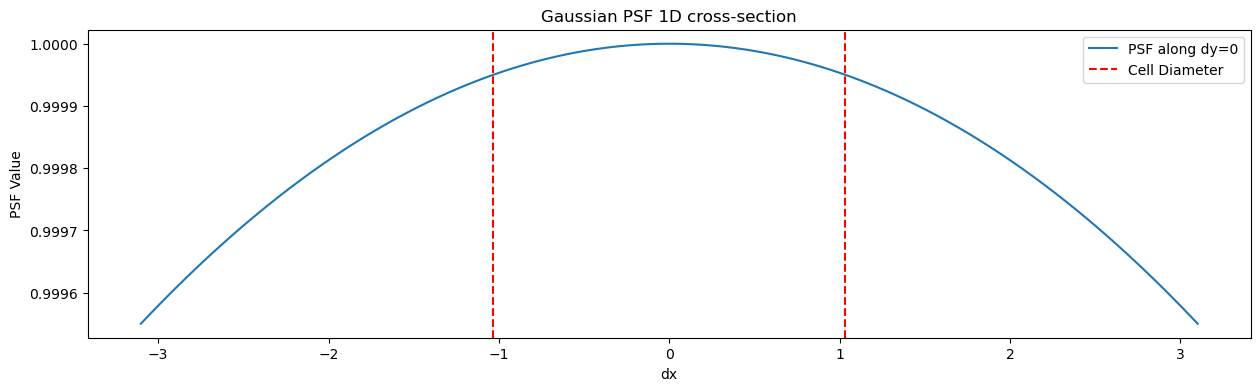

In [ ]:
plt.figure()
x = np.linspace(-3* cell_radius, 3*cell_radius, 200)
plt.figure(figsize=(15,4))
plt.plot(x, cell_psf(x, 0), label='PSF along dy=0')
# put vertical lines at +/- cell_diameter
plt.axvline(cell_radius, color='r', linestyle='--', label='Cell Diameter ')
plt.axvline(-cell_radius, color='r', linestyle='--')
plt.title('Gaussian PSF 1D cross-section')
plt.xlabel('dx')
plt.ylabel('PSF Value')
plt.legend()
plt.show()

In [ ]:

processed_partition = process_partition(
    gdf, 
    nside, 
    mode, 
    base_index=None,
    lon_convention=lon_convention,
    data_psf=None,
    cell_psf=cell_psf
    )

print(processed_partition.describe())

2026-02-03 13:20:07,357 INFO Partition (lon_convention=0_360): processed 3029 geometries, dropped 2 (0.1%) total [pre-filter: 2, post-processing: 0]


         source_id   healpix_id       weight
count  3539.000000       3539.0  3539.000000
mean   1484.089008  5784.662617     0.116974
std     877.023929  2786.253912     0.056835
min       0.000000       1360.0     0.052385
25%     723.500000       1887.0     0.068813
50%    1467.000000       6381.0     0.092915
75%    2249.500000       7114.0     0.171715
max    3028.000000       9588.0     0.231170


<Axes: >

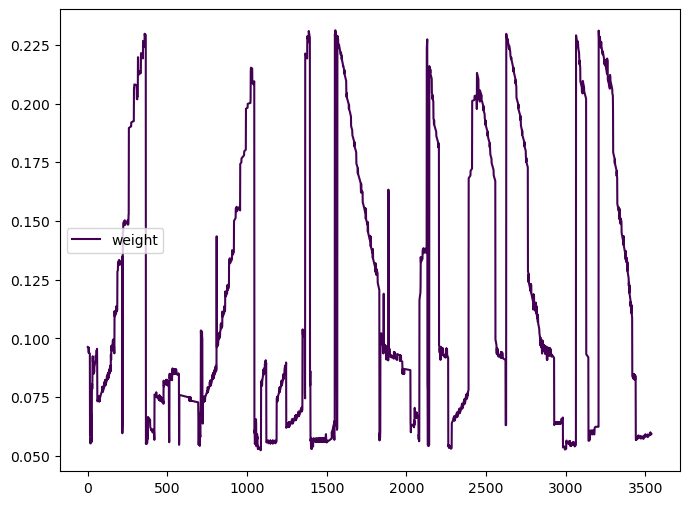

In [ ]:
processed_partition['weight'].plot( cmap='viridis', figsize=(8,6), legend=True)

In [ ]:
processed_partition.groupby('healpix_id').agg(len)[['weight']].sort_values(by='weight', ascending=False).head(10)

,weight
healpix_id,
6742,197
6300,84
9495,80
1494,73
6294,72
6381,71
6394,70
6748,66
1372,63


In [ ]:
processed_partition.groupby('healpix_id').agg(sum)[['weight']].sort_values(by='weight', ascending=False).head(10)

/tmp/ipykernel_3508251/3028256981.py:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  processed_partition.groupby('healpix_id').agg(sum)[['weight']].sort_values(by='weight', ascending=False).head(10)


,weight
healpix_id,
6742,18.155711
1494,14.655453
1404,11.186208
1372,10.915641
1887,10.366320
1879,10.354245
1398,9.979602
1909,9.568294
1500,9.174513


In [ ]:
healpix_id = 6374
cell = processed_partition.query(f'healpix_id == {healpix_id}')

cell

,source_id,healpix_id,weight
110,74,6374,0.080002
112,75,6374,0.080246
113,76,6374,0.080493
114,77,6374,0.080744
115,78,6374,0.081001
...,...,...,...
1395,1163,6374,0.082103
3434,2934,6374,0.082484
3436,2935,6374,0.082365
3438,2936,6374,0.082261


In [ ]:
import healpy as hp
lon, lat = 175, 43  # Example from your data
theta = np.radians(90 - lat)
phi = np.radians(lon)
hid = hp.ang2pix(nside, theta, phi, nest=True)
print(hid)

from healpyxel.sidecar import get_healpix_cell_geometry

# Return a shapely Polygon for the given HEALPix cell.
# Uses healpy boundaries (in degrees, lon/lat).

print(get_healpix_cell_geometry(hid, nside=nside,nest=False).exterior.xy)

1372
(array('d', [-32.94412311703627, -33.52804087419743, -34.82172104878954, -34.23461408949813, -32.94412311703627]), array('d', [100.70419447584689, 102.7155086769465, 102.67406996768031, 100.66793719134546, 100.70419447584689]))


In [ ]:
gdf_cell = gdf.iloc[cell['source_id'].values].copy()

<Axes: >

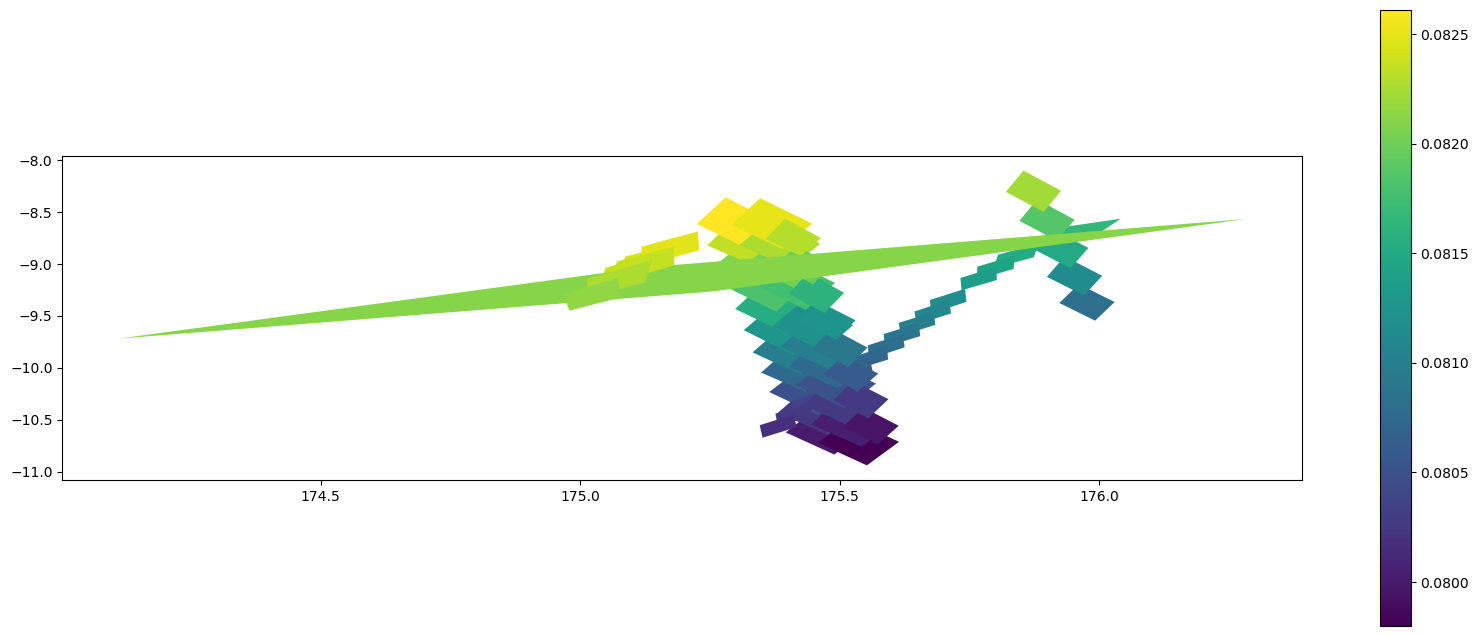

In [ ]:

gdf_cell['weight'] = cell.set_index('source_id')['weight']
fig, ax = plt.subplots(figsize=(20,8))
gdf_cell.plot(aspect=0.2, ax=ax, column='weight', legend=True)

<Axes: >

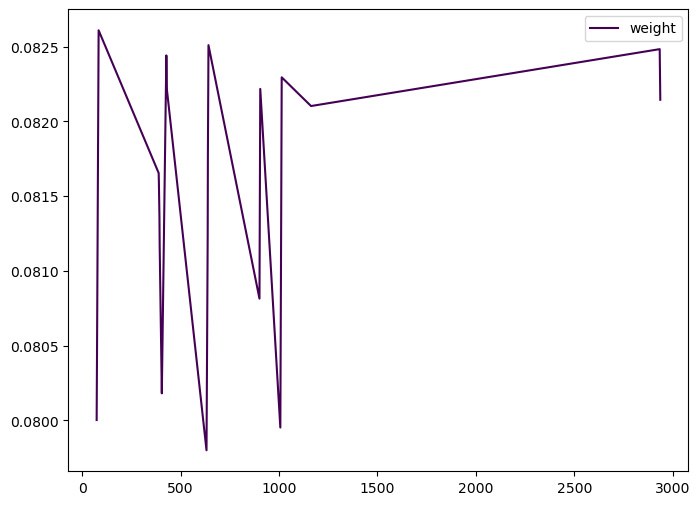

In [ ]:
gdf_cell['weight'].plot( cmap='viridis', figsize=(8,6), legend=True)

[<matplotlib.patches.Polygon>]

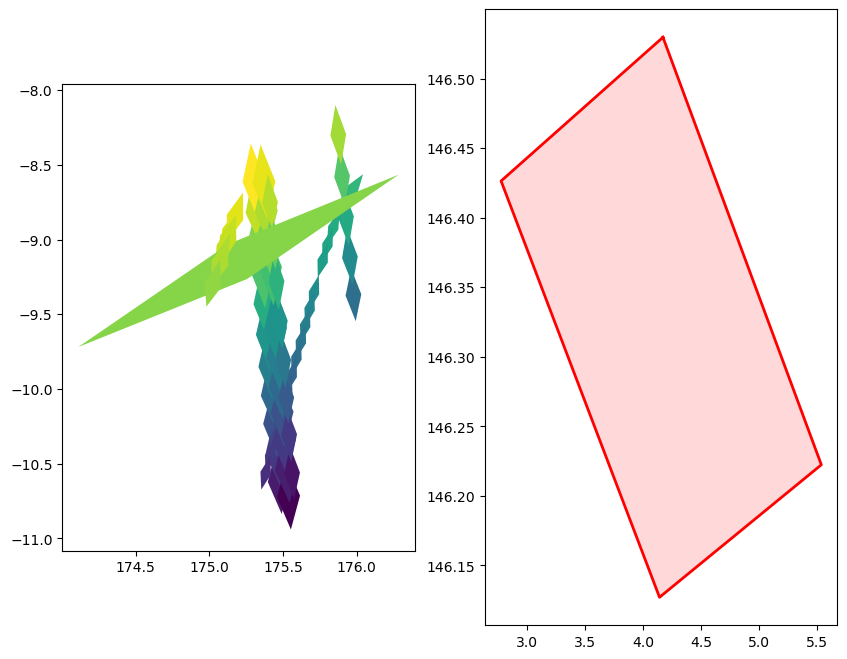

In [ ]:
from sqlalchemy import column


fig, axs = plt.subplots(ncols=2, figsize=(10,8))
gdf_cell.plot(ax=axs[0], aspect='auto', column='weight')
poly = get_healpix_cell_geometry(healpix_id, nside=nside)
x_poly, y_poly = poly.exterior.xy

axs[1].plot(x_poly, y_poly, color='red', linewidth=2)
axs[1].fill(x_poly, y_poly, facecolor='red', alpha=0.15)